In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **pyprobe library based battery data processing**

Processed file written to: /content/drive/MyDrive/Colab Notebooks/pyprobe_lib/dataset/A_Test.parquet


17:36:28 | WARNING | pyprobe.utils:wrapper:109 - Deprecation Warning: Use set_soc instead. | Context: {}


info={'Name': 'Sample', 'Chemistry': 'NMC622', 'Nominal Capacity [Ah]': 20} procedure={'CustomTest': Procedure(lf=<LazyFrame at 0x7AA15A7246E0>, info={'Name': 'Sample', 'Chemistry': 'NMC622', 'Nominal Capacity [Ah]': 20}, column_definitions={'Date': 'The timestamp of the data point. Type: datetime.', 'Time': 'The time passed from the start of the procedure.', 'Step': 'The step number.', 'Cycle': 'The cycle number.', 'Event': 'The event number. Counts the changes in cycles and steps.', 'Current': 'The current through the cell.', 'Voltage': 'The terminal voltage.', 'Capacity': 'The net charge passed since the start of the procedure.', 'Temperature': 'The temperature of the cell.', 'Procedure Time': 'Time elapsed since beginning of procedure.', 'Procedure Capacity': 'The net charge passed since beginning of procedure.'}, step_descriptions={'Step': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14], 'Description': ['Rest', 'Charge until upper cutoff voltage', 'Rest', 'Discharge until lower cu

/usr/local/lib/python3.12/dist-packages/pyprobe/filters.py:128: UserWarning: No cycle information provided. Cycles will be inferred from the step numbers.
  warnings.warn(


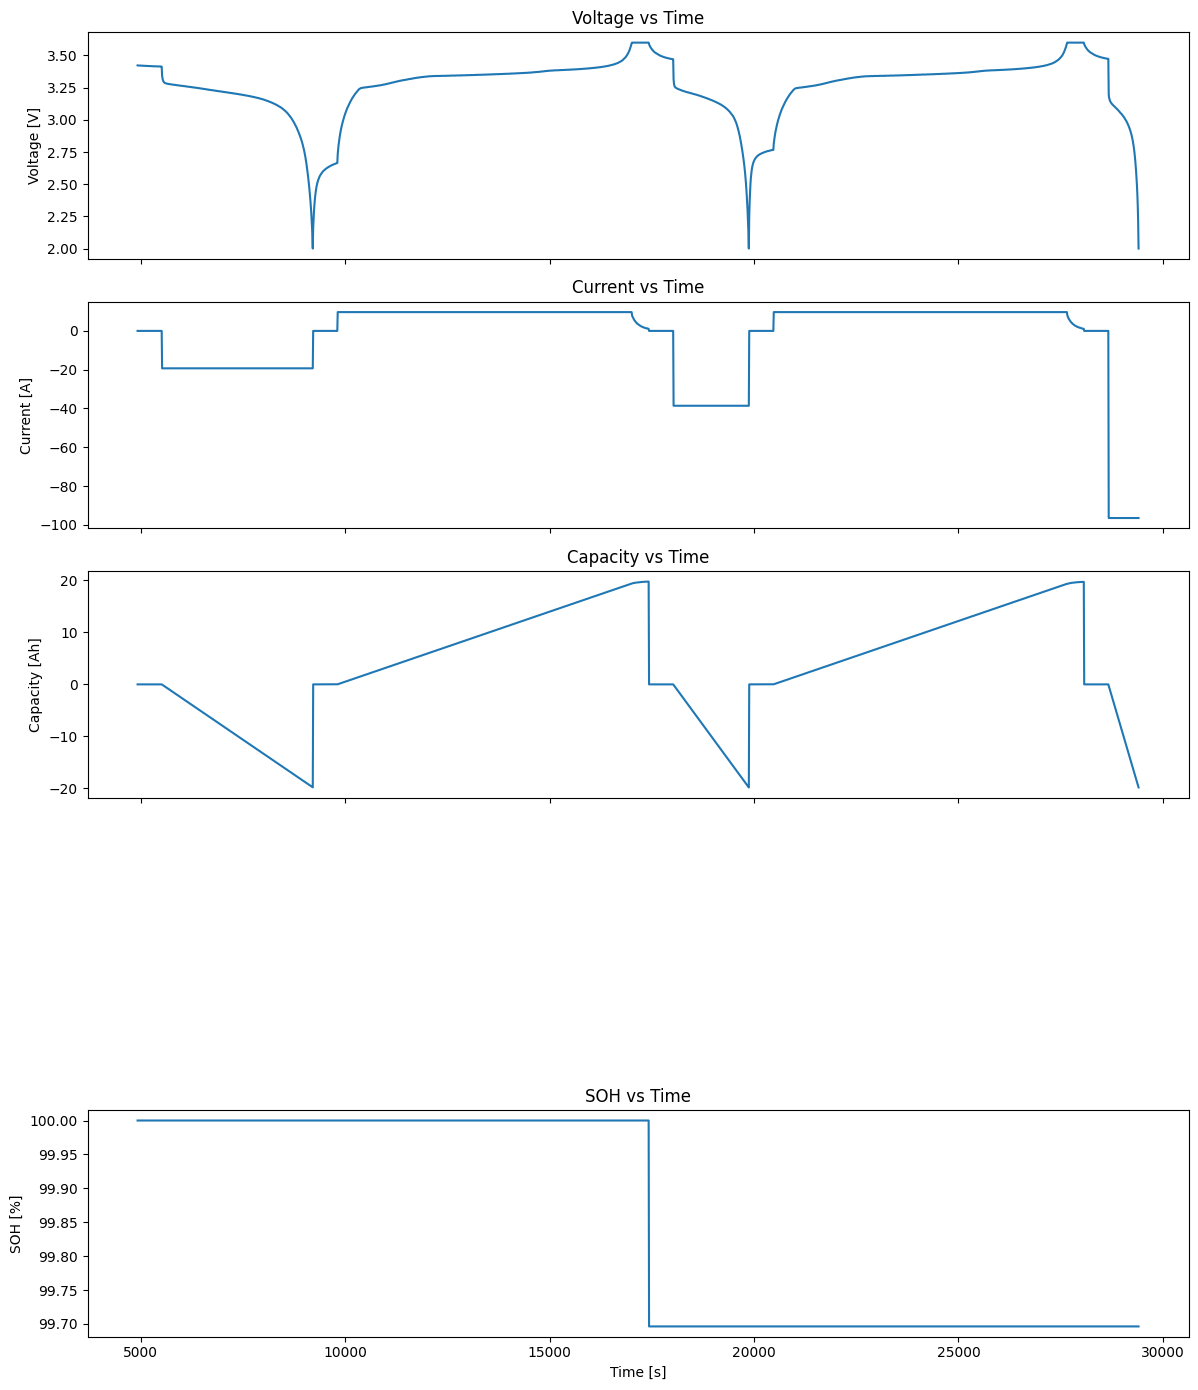

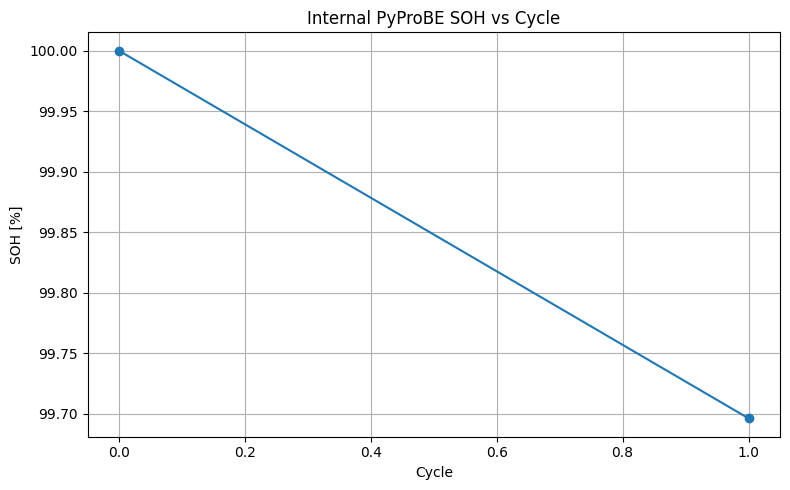

<Figure size 640x480 with 0 Axes>

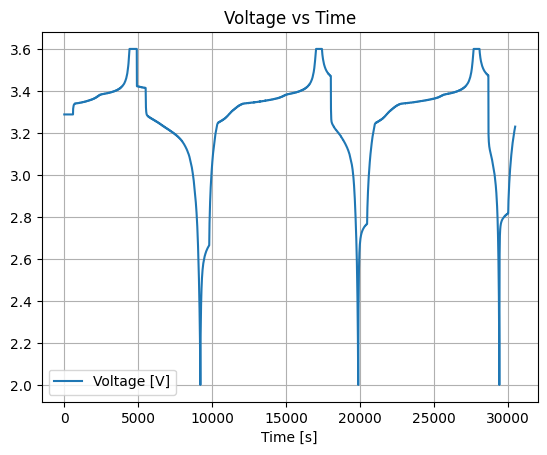

<Figure size 640x480 with 0 Axes>

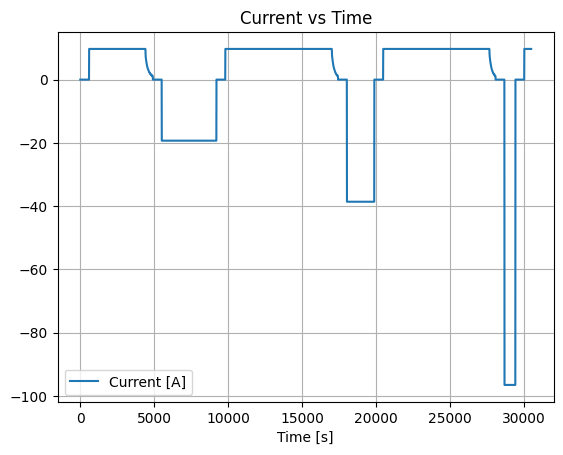

<Figure size 640x480 with 0 Axes>

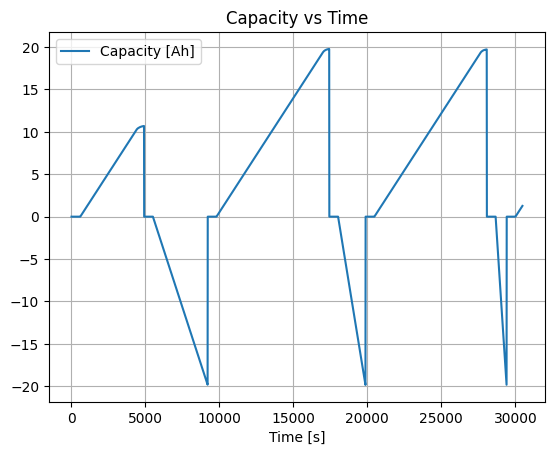

<Figure size 640x480 with 0 Axes>

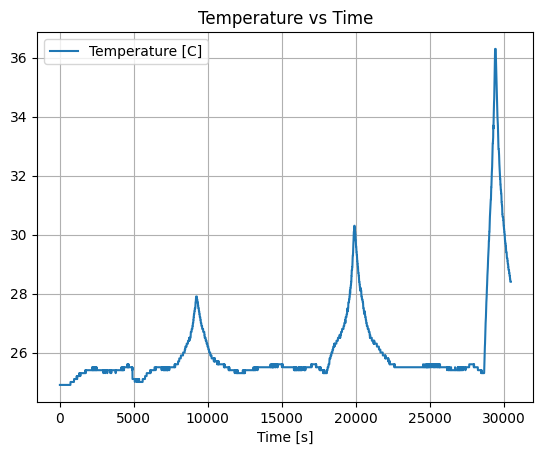

<Figure size 640x480 with 0 Axes>

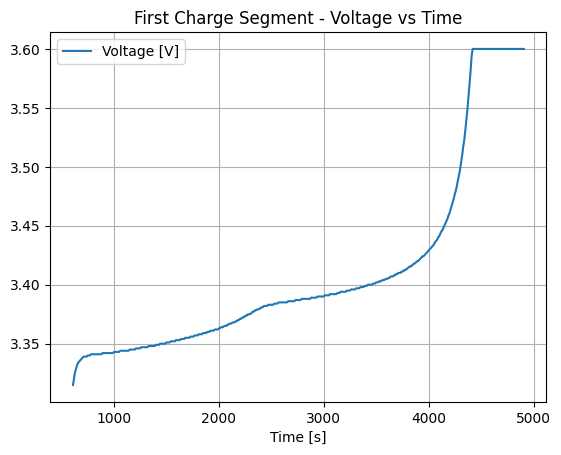

<Figure size 640x480 with 0 Axes>

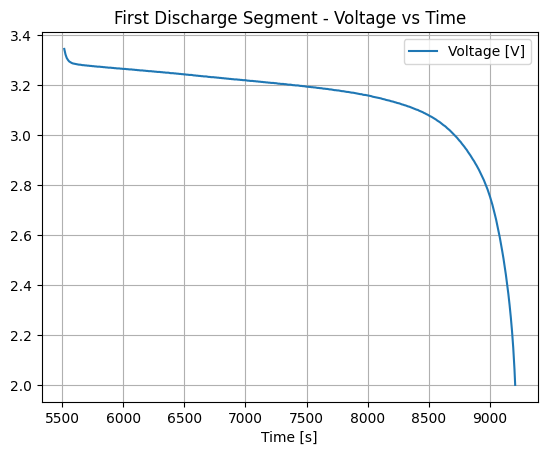

<Figure size 640x480 with 0 Axes>

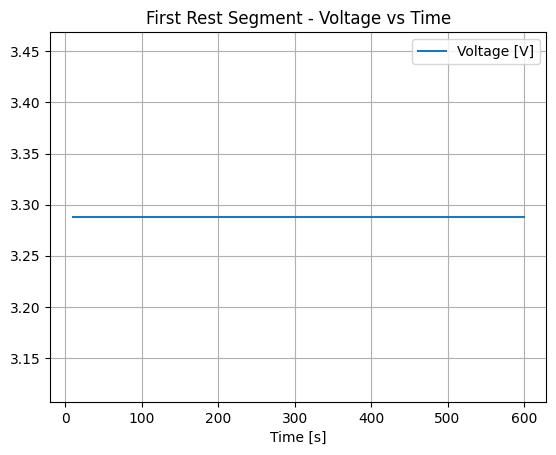

<Figure size 640x480 with 0 Axes>

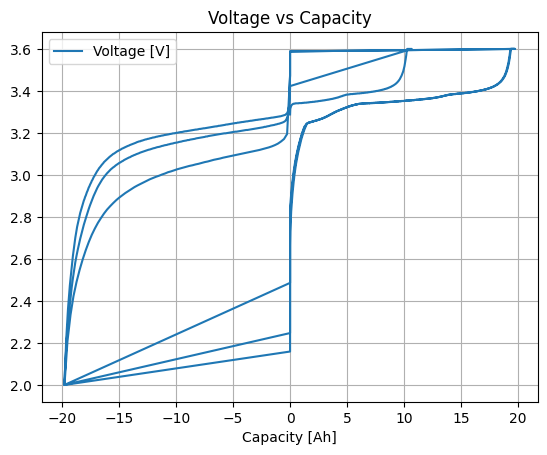

<Figure size 640x480 with 0 Axes>

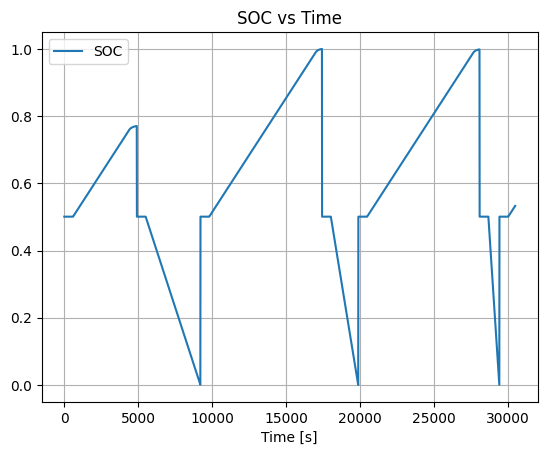

In [ ]:
"""
Introduction

Link: https://github.com/ImperialCollegeLondon/PyProBE

PyProBE (Python Processing for Battery Experiments) is a Python package designed to simplify and accelerate the process of analysing data from battery cyclers.
We will be using it to calculate SOC and SOH from the battery dataset and use it for AI based analysis
"""

%pip install matplotlib
%pip install PyProBE-Data

import pandas as pd
import pyprobe
from typing import ClassVar
from pathlib import Path
from pyprobe.cyclers.basecycler import BaseCycler
import matplotlib.pyplot as plt
import polars as pl
from pyprobe.cell import Cell, process_cycler_data
from pyprobe.cyclers.column_maps import (
    CastAndRenameMap,
    DateTimeMap,
)
from pyprobe.analysis import cycling
from pyprobe.filters import get_cycle_column

# ---------------------------------------------------
# Load raw CSV
# ---------------------------------------------------
csv_path = "/content/drive/MyDrive/Colab Notebooks/pyprobe_lib/dataset/A_Test.csv"
parquet_path = "/content/drive/MyDrive/Colab Notebooks/pyprobe_lib/dataset/A_Test.parquet"
readme_file = "/content/drive/MyDrive/Colab Notebooks/pyprobe_lib/dataset/README.yaml"
output_csv = "/content/drive/MyDrive/Colab Notebooks/pyprobe_lib/dataset/A_Test_processed.csv"

# ---------------------------------------------------
# Column importers for the generic cycler
# These tell PyProBE how to map your CSV columns
# into PyProBE standard columns.
# ---------------------------------------------------
column_importers = [
    # Timestamp / date-time
    #DateTimeMap(
    #    required_cycler_col="Real Time",
    #    datetime_format="%d/%m/%Y %H:%M:%S",
    #),
    # Time
    CastAndRenameMap(
        pyprobe_name="Time [s]",
        required_cycler_col="Total Time, S",
        data_type=pl.Float64,
    ),

    # Step / cycle
    CastAndRenameMap(
        pyprobe_name="Step",
        required_cycler_col="Step",
        data_type=pl.Int64,
    ),
    #CastAndRenameMap(
    #    pyprobe_name="Cycle",
    #    required_cycler_col="Cycle",
    #    data_type=pl.Int64,
    #),

    # Electrical channels
    CastAndRenameMap(
        pyprobe_name="Current [A]",
        required_cycler_col="Current, A",
        data_type=pl.Float64,
    ),
    CastAndRenameMap(
        pyprobe_name="Voltage [V]",
        required_cycler_col="Voltage, V",
        data_type=pl.Float64,
    ),

    # Capacity channels
    CastAndRenameMap(
        pyprobe_name="Charge Capacity [Ah]",
        required_cycler_col="Amp Hours Charge, AH",
        data_type=pl.Float64,
    ),
    CastAndRenameMap(
        pyprobe_name="Discharge Capacity [Ah]",
        required_cycler_col="Amp Hours Discharge, AH",
        data_type=pl.Float64,
    ),
    CastAndRenameMap(
        pyprobe_name="Capacity [Ah]",
        required_cycler_col="Amp-Hours, AH",
        data_type=pl.Float64,
    ),

    # Temperature
    CastAndRenameMap(
        pyprobe_name="Temperature [C]",
        required_cycler_col="Temperature A1, degC",
        data_type=pl.Float64,
    ),
]

# ---------------------------------------------------
# Convert generic CSV -> PyProBE parquet
# ---------------------------------------------------
processed_path = process_cycler_data(
    cycler="generic",
    input_data_path=csv_path,
    output_data_path=parquet_path,
    column_importers=column_importers,
    compression_priority="performance",
    overwrite_existing=False,
)

print(f"Processed file written to: {processed_path}")

# ---------------------------------------------------
# Create a PyProBE Cell and import the parquet
# ---------------------------------------------------
info_dictionary = {
    "Name": "Sample",
    "Chemistry": "NMC622",
    "Nominal Capacity [Ah]":20
}
#info_dictionary = {
#    "Name": "Sample",
#    "Chemistry": "NMC622",
#}
cell = Cell(info=info_dictionary)

cell.import_data(
    procedure_name="CustomTest",
    data_path=processed_path,
)

# ---------------------------------------------------
# Sanity check
# ---------------------------------------------------
print(cell)
print(cell.procedure)


# Import into Cell object
cell = pyprobe.Cell(info=info_dictionary)
cell.import_data(procedure_name="CustomTest", data_path="/content/drive/MyDrive/Colab Notebooks/pyprobe_lib/dataset/A_Test.parquet")

# Select the imported PyProBE procedure
proc = cell.procedure["CustomTest"]
exp = proc.experiment("Main Cycling")
# Add SOC column to the procedure
#proc.set_SOC(reference_capacity=REFERENCE_CAPACITY_AH)
proc.set_SOC()

# Quick check: print the first rows including SOC
soc_df = proc.data
try:
    soc_df = soc_df.collect()  # if LazyFrame
except Exception:
    pass

print("=== SOC DATA PREVIEW ===")
"""
print(soc_df.select([c for c in soc_df.columns if c in [
    "Time [s]", "Cycle", "Step", "Current [A]", "Voltage [V]", "Capacity [Ah]", "SOC"
]]).head(20))
"""
print(soc_df.head(20))

# ---------------------------------------------------
# 1) Run PyProBE's internal SOH calculation
#
# IMPORTANT:
# - dchg_before_chg=True  -> if your cycle structure is discharge -> charge
# - dchg_before_chg=False -> if your cycle structure is charge -> discharge
#
# Your dataset appears to begin with charge in the visible portion,
# so False is usually the better first choice.
# ---------------------------------------------------

soh_result = cycling.summary(
    input_data=exp,
    dchg_before_chg=False,
)

# Build experiment dataframe with cycle column from README
exp_df = get_cycle_column(exp)
if isinstance(exp_df, pl.LazyFrame):
    exp_df = exp_df.collect()

# ---------------------------------------------------
# 2) Collect the returned SOH result dataframe
# ---------------------------------------------------
soh_df = soh_result.data
if isinstance(soh_df, pl.LazyFrame):
    soh_df = soh_df.collect()

print("===== INTERNAL SOH SUMMARY FROM PYPROBE =====")
print(soh_df)
print("\nColumns returned by cycling.summary():")
print(soh_df.columns)

# ---------------------------------------------------
# 3) Identify the SOH-like column
# PyProBE's internal output can vary by version, so detect it robustly
# ---------------------------------------------------
candidate_soh_cols = [
    c for c in soh_df.columns
    if "SOH" in c or "State of Health" in c or "Capacity" in c
]

if len(candidate_soh_cols) == 0:
    raise ValueError(
        "No SOH-like column found in PyProBE cycling.summary() output. "
        "Inspect soh_df.columns and update the column selection."
    )

# Prefer a true SOH column if present
preferred = [c for c in candidate_soh_cols if "SOH" in c or "State of Health" in c]
soh_col = preferred[0] if preferred else candidate_soh_cols[0]

print(f"\nUsing SOH column: {soh_col}")

# ---------------------------------------------------
# 4) Rename the selected SOH column to a clean standard name
#    and keep only Cycle + SOH
# ---------------------------------------------------
if "Cycle" not in soh_df.columns:
    raise ValueError(
        "PyProBE SOH summary does not contain a 'Cycle' column, "
        "so it cannot be joined back to the full dataframe automatically."
    )

soh_cycle_df = (
    soh_df.select(["Cycle", soh_col])
          .rename({soh_col: "SOH [%]"})
)

print("\n===== CYCLE-LEVEL SOH TABLE =====")
print(soh_cycle_df)

# ---------------------------------------------------
# 5) Collect the full imported procedure dataframe
# ---------------------------------------------------
full_df = proc.data
if isinstance(full_df, pl.LazyFrame):
    full_df = full_df.collect()


# ---------------------------------------------------
# 7) Print a clean analysis view
# ---------------------------------------------------
preferred_cols = [
    "Time [s]",
    "Cycle",
    "Step",
    "Event",
    "Current [A]",
    "Voltage [V]",
    "Capacity [Ah]",
    "SOC",
    "SOH [%]",
    "Temperature [C]",
]

analysis_df = exp_df.join(
    soh_cycle_df,
    on="Cycle",
    how="left"
)
final_df = soc_df.join(
    analysis_df.select(["Time [s]", "SOH [%]"]),
    on="Time [s]",
    how="left"
)
final_df_filled = final_df.with_columns(
    pl.col("SOH [%]").fill_null(strategy="forward").fill_null(strategy="backward"),
    (pl.col("SOC")*100).alias("SOC [%]")
)

print("=== ANALYSIS DF WITH INTERNAL SOH ===")
print(
    analysis_df.select(
        [c for c in [
            "Time [s]", "Cycle", "Step", "Event",
            "Current [A]", "Voltage [V]", "Capacity [Ah]", "SOH [%]"
        ] if c in analysis_df.columns]
    ).head(30)
)
print("========final df=========")
print(final_df_filled.tail(30))

available_cols = [c for c in preferred_cols if c in analysis_df.columns]

print("\n===== ANALYSIS DATAFRAME WITH INTERNAL SOH =====")
print(analysis_df.select(available_cols).head(30))

print("\n===== DATA SHAPE =====")
print(f"Rows: {analysis_df.height}, Columns: {analysis_df.width}")

# ---------------------------------------------------
# 8) Save for downstream analysis
# ---------------------------------------------------
final_df_filled.write_csv(output_csv)
print("\nSaved: %s"%output_csv)


print("=== EXPERIMENT NAMES ===")
print(proc.experiment_names)

print("\n=== STEP DESCRIPTIONS ===")
print(proc.step_descriptions)

print("\n=== CYCLE INFO FROM README ===")
print(proc.cycle_info)



cycle_df = get_cycle_column(proc)
if isinstance(cycle_df, pl.LazyFrame):
    cycle_df = cycle_df.collect()


print("Experiment names:", proc.experiment_names)
print("Experiment cycle_info:", exp.cycle_info)

print(cycle_df.select(["Step", "Cycle"]).head(50))
print(cycle_df.select("Cycle").unique().sort("Cycle"))


print("\n=== GENERATED CYCLE COLUMN PREVIEW ===")
cols_to_show = [c for c in ["Time [s]", "Step", "Cycle", "Event", "Current [A]", "Voltage [V]"] if c in cycle_df.columns]
print(cycle_df.select(cols_to_show).head(50))

print("\n=== UNIQUE CYCLE VALUES ===")
print(cycle_df.select("Cycle").unique().sort("Cycle"))

print("\n=== ROW COUNT PER CYCLE ===")
print(
    cycle_df.group_by("Cycle")
            .agg(pl.len().alias("Rows"))
            .sort("Cycle")
)

# ---------------------------------------------------
# 9) Plot the full dataframe with SOH added
# ---------------------------------------------------
pdf = analysis_df.select(available_cols).to_pandas()
soh_pdf = soh_cycle_df.to_pandas()

fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

# Voltage vs Time
axes[0].plot(pdf["Time [s]"], pdf["Voltage [V]"])
axes[0].set_ylabel("Voltage [V]")
axes[0].set_title("Voltage vs Time")

# Current vs Time
axes[1].plot(pdf["Time [s]"], pdf["Current [A]"])
axes[1].set_ylabel("Current [A]")
axes[1].set_title("Current vs Time")

# Capacity vs Time
axes[2].plot(pdf["Time [s]"], pdf["Capacity [Ah]"])
axes[2].set_ylabel("Capacity [Ah]")
axes[2].set_title("Capacity vs Time")

# SOC vs Time (only if SOC already exists)
if "SOC" in pdf.columns:
    axes[3].plot(pdf["Time [s]"], pdf["SOC"])
    axes[3].set_ylabel("SOC")
    axes[3].set_title("SOC vs Time")
else:
    axes[3].set_visible(False)

# SOH vs Time (SOH repeated across rows within each cycle)
axes[4].plot(pdf["Time [s]"], pdf["SOH [%]"])
axes[4].set_ylabel("SOH [%]")
axes[4].set_xlabel("Time [s]")
axes[4].set_title("SOH vs Time")

plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 10) Cleaner plot: SOH vs Cycle
# ---------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(soh_pdf["Cycle"], soh_pdf["SOH [%]"], marker="o")
plt.xlabel("Cycle")
plt.ylabel("SOH [%]")
plt.title("Internal PyProBE SOH vs Cycle")
plt.grid(True)
plt.tight_layout()
plt.show()

# Voltage vs Time
plt.figure()
proc.plot(
    x="Time [s]",
    y="Voltage [V]",
    grid=True,
    title="Voltage vs Time",
)
plt.show()

# Current vs Time
plt.figure()
proc.plot(
    x="Time [s]",
    y="Current [A]",
    grid=True,
    title="Current vs Time",
)
plt.show()

# Capacity vs Time
plt.figure()
proc.plot(
    x="Time [s]",
    y="Capacity [Ah]",
    grid=True,
    title="Capacity vs Time",
)
plt.show()

# Temperature vs Time (only if Temperature exists in your imported data)
plt.figure()
proc.plot(
    x="Time [s]",
    y="Temperature [C]",
    grid=True,
    title="Temperature vs Time",
)
plt.show()


# First charge segment
charge_0 = proc.charge(0)

plt.figure()
charge_0.plot(
    x="Time [s]",
    y="Voltage [V]",
    grid=True,
    title="First Charge Segment - Voltage vs Time",
)
plt.show()

# First discharge segment
discharge_0 = proc.discharge(0)

plt.figure()
discharge_0.plot(
    x="Time [s]",
    y="Voltage [V]",
    grid=True,
    title="First Discharge Segment - Voltage vs Time",
)
plt.show()

# First rest segment
rest_0 = proc.rest(0)

plt.figure()
rest_0.plot(
    x="Time [s]",
    y="Voltage [V]",
    grid=True,
    title="First Rest Segment - Voltage vs Time",
)
plt.show()


plt.figure()
proc.plot(
    x="Capacity [Ah]",
    y="Voltage [V]",
    grid=True,
    title="Voltage vs Capacity",
)
plt.show()

# Plot SOC vs time using PyProBE's built-in plot()
plt.figure()
proc.plot(
    x="Time [s]",
    y="SOC",
    grid=True,
    title="SOC vs Time",
)
plt.show()





# **AI model**

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)
from tensorflow.keras import models, layers
from sklearn.preprocessing import StandardScaler

# Load the dataset
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/pyprobe_lib/dataset/A_Test_processed.csv')

print(data.columns.tolist())
# Define features (X) and target (y)
X = data[['Voltage [V]','Current [A]','Temperature [C]']].values.astype(np.float32)  # Features
y = data[['SOC [%]','SOH [%]']].values.astype(np.float32)  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Normalization layer inside model
normalizer = layers.Normalization(axis=-1, name="input_standardization")
normalizer.adapt(X_train)


"""
ST Edge AI Core 4.0 lists LSTM and GRU as supported Keras recurrent layers, and its Keras support page also documents recurrent-layer handling such as Bidirectional support with LSTM, GRU, and SimpleRNN. [stedgeai-dc.st.com]
But for STM32, keep these cautions in mind

recurrent models are usually heavier than Dense-only or small Conv1D models
they may be harder to optimize for small MCUs
if you ever move to stateful LSTM/GRU, ST documents extra restrictions such as batch-size 1 only and return_state not supported for that special case [stedgeai-dc.st.com]

So for now, if you use recurrent layers, keep them:

stateless
small
single-layer
"""

"""
What not to do with your current input size
I would avoid this exact stack:

layers.Reshape((3, 1)),
layers.Conv1D(64, 3, activation='relu'),
layers.MaxPooling1D(2),
layers.SimpleRNN(64, return_sequences=True),
layers.LSTM(64, return_sequences=True),
layers.Flatten(),
layers.Dense(64, activation='relu'),
layers.Dense(32, activation='relu'),
layers.Dense(2)

Why?
Because with input length 3:

Conv1D(kernel_size=3) reduces sequence length to 1
MaxPooling1D(2) no longer makes sense
SimpleRNN and LSTM after a length-1 sequence add little value
model complexity goes up a lot without much signal benefit
"""

"""
Which one should you use?
If your priority is STM32 success
Use:
Dense-only
or
Small Conv1D
If your priority is experimenting with sequence modeling
Use:
LSTM-only
or
SimpleRNN-only
But I would not use Conv1D + SimpleRNN + LSTM together for this dataset shape.

My recommendation for you right now
For your exact dataset and STM32 deployment path, I would choose this order:

Dense-only with normalization inside model
Conv1D(32, kernel=2) + GlobalAveragePooling1D
LSTM(16) only, if you really want recurrent behavior
"""

model = models.Sequential([
    layers.Input(shape=(3,), name="raw_input"),
    normalizer,
    layers.Reshape((3, 1)),                 # convert 3 features to a length-3 sequence

    # Small CNN block
    layers.Conv1D(32, kernel_size=2, activation='relu',name="cnn_layer"),
    layers.GlobalAveragePooling1D(),

    #Simple RNN block while enabling enable reshape block
    #layers.SimpleRNN(16, return_sequences=False),

    #LSTM while enabling enable reshape block
    #layers.LSTM(16, return_sequences=False),
    layers.Dense(64, activation='relu',name="dense_layer_1"),
    layers.Dense(32, activation='relu',name="dense_layer_2"),
    layers.Dense(2,name="dense_layer_3")
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)
#model.save('/content/drive/MyDrive/Colab Notebooks/pyprobe_lib/NET_model.h5',include_optimizer=False)


# Convert to tflite model for importing with STMCube AI Studio
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("/content/drive/MyDrive/Colab Notebooks/pyprobe_lib/NET_model.tflite", "wb") as f:
    f.write(tflite_model)

# Save RAW input CSV because normalization is inside the model
pd.DataFrame(X_test).to_csv(
    '/content/drive/MyDrive/Colab Notebooks/pyprobe_lib/dataset/input_test_dataset.csv',
    header=False, index=False
)

# Save ground-truth output CSV
pd.DataFrame(y_test).to_csv(
    '/content/drive/MyDrive/Colab Notebooks/pyprobe_lib/dataset/output_test_dataset.csv',
    header=False, index=False
)


# Print model info
model.summary()
print(model.input_shape)
print(model.output_shape)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model using the metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)

# Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs(np.array(y_test) - np.array(y_pred)) / np.array(y_test)) * 100

# R-squared
# R-squared is usually used in regression, but it can still be computed here for binary classification as a performance measure.
r_squared = r2_score(y_test, y_pred)

# Print the metrics
print(f"R-squared: {r_squared:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")


['Time [s]', 'Step', 'Event', 'Current [A]', 'Voltage [V]', 'Capacity [Ah]', 'Procedure Capacity [Ah]', 'Charge Capacity [Ah]', 'Temperature [C]', 'Discharge Capacity [Ah]', 'SOC', 'Procedure Time [s]', 'SOH [%]', 'SOC [%]']
Epoch 1/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 6883.0088 - mae: 78.7203
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3922.9717 - mae: 56.7006
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 505.6286 - mae: 16.1740
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 307.4543 - mae: 12.8835
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 263.3641 - mae: 12.1833
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 205.8270 - mae: 10.8707
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 141.4144 - mae: 9.0784
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 108.6131 - mae: 7.8991
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 97.0110 - mae: 7.3897
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_standardization           │ (None, 3)              │             7 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 3, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_layer (Conv1D)              │ (None, 2, 32)          │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer_1 (Dense)           │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer_2 (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer_3 (Dense)           │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,071 (51.07 KB)

 Trainable params: 4,354 (17.01 KB)

 Non-trainable params: 7 (32.00 B)

 Optimizer params: 8,710 (34.03 KB)

(None, 3)
(None, 2)
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
R-squared: -870.6606
Mean Squared Error (MSE): 85.0067
Root Mean Squared Error (RMSE): 9.2199
Mean Absolute Percentage Error (MAPE): 16.1371
Mean Absolute Error (MAE): 6.9339
